# **Clasificación de salida del cliente del banco**

En esta etapa, se busca predecir si un cliente del banco va abandonar este o va a continuar.

1. Preparación de Datos
2. División de los datos 70-30
3. Aprendizaje del Modelo: Tree, Knn, NN, SVM, RandomForest
4. Evaluación del Modelo: matriz de confusion, P,R, ROC
5. Guardar el modelo


In [104]:
#Importamos librerías básicas
import pandas as pd # manipulacion dataframes
import numpy as np  # matrices y vectores
import matplotlib.pyplot as plt #gráfica

# 1. Preparación de Datos

In [105]:
#Cargamos los datos preparados, resultado de archivo 1.calidad_datos.ipynb
data = pd.read_excel("datos_P_Churn_Modelling.xlsx")
data.head()

,Unnamed: 0,Geography,Gender,Age,Balance,NumOfProducts,IsActiveMember,Exited
0,0,France,Female,42.0,0.00,1,Si,Si
1,1,Spain,Female,41.0,83807.86,1,Si,No
2,2,France,Female,42.0,159660.80,3,No,Si
3,3,France,Female,39.0,0.00,2,No,No
4,4,Spain,Female,43.0,125510.82,1,Si,No


In [106]:
#Conocemos los datos
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15920 entries, 0 to 15919
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Unnamed: 0      15920 non-null  int64  
 1   Geography       15920 non-null  object 
 2   Gender          15920 non-null  object 
 3   Age             15920 non-null  float64
 4   Balance         15920 non-null  float64
 5   NumOfProducts   15920 non-null  int64  
 6   IsActiveMember  15920 non-null  object 
 7   Exited          15920 non-null  object 
dtypes: float64(2), int64(2), object(4)
memory usage: 995.1+ KB


In [107]:
#Corrección de variables categóricas
data['Geography'] = data['Geography'].astype('category')
data['Gender'] = data['Gender'].astype('category')
data['NumOfProducts'] = data['NumOfProducts'].astype('category')
data['IsActiveMember'] = data['IsActiveMember'].astype('category')
data['Exited'] = data['Exited'].astype('category')
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15920 entries, 0 to 15919
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   Unnamed: 0      15920 non-null  int64   
 1   Geography       15920 non-null  category
 2   Gender          15920 non-null  category
 3   Age             15920 non-null  float64 
 4   Balance         15920 non-null  float64 
 5   NumOfProducts   15920 non-null  category
 6   IsActiveMember  15920 non-null  category
 7   Exited          15920 non-null  category
dtypes: category(5), float64(2), int64(1)
memory usage: 451.7 KB


In [108]:
data.head()

,Unnamed: 0,Geography,Gender,Age,Balance,NumOfProducts,IsActiveMember,Exited
0,0,France,Female,42.0,0.00,1,Si,Si
1,1,Spain,Female,41.0,83807.86,1,Si,No
2,2,France,Female,42.0,159660.80,3,No,Si
3,3,France,Female,39.0,0.00,2,No,No
4,4,Spain,Female,43.0,125510.82,1,Si,No


In [109]:
# Eliminar variable Unnamed:0 (IRRELEVANTE)
data = data.drop('Unnamed: 0',axis=1) #Eaxis=1 indica que es una columna
data.head()

,Geography,Gender,Age,Balance,NumOfProducts,IsActiveMember,Exited
0,France,Female,42.0,0.00,1,Si,Si
1,Spain,Female,41.0,83807.86,1,Si,No
2,France,Female,42.0,159660.80,3,No,Si
3,France,Female,39.0,0.00,2,No,No
4,Spain,Female,43.0,125510.82,1,Si,No


<Axes: >

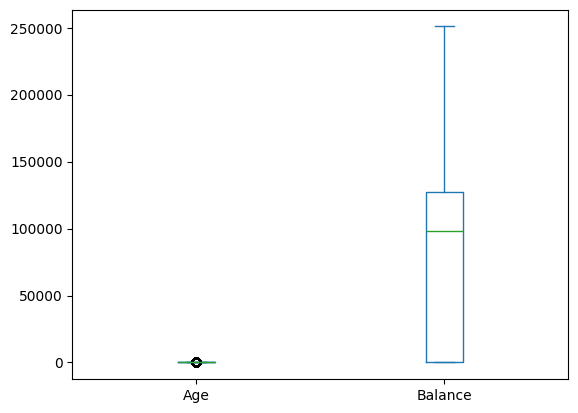

In [110]:
#Descripción variables numérica
data.plot(kind='box')

<Axes: xlabel='Geography'>

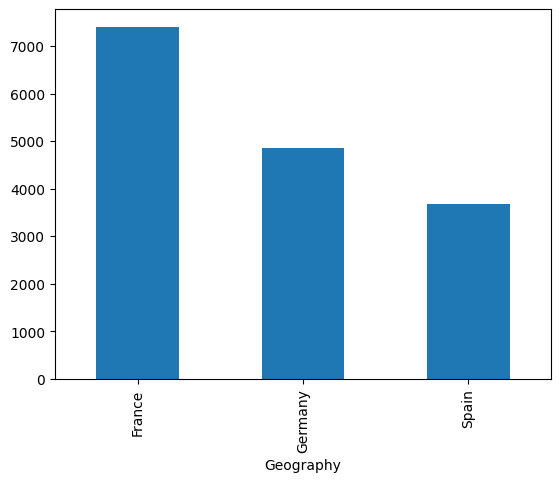

In [111]:
#Descripción variables categóricas
data['Geography'].value_counts().plot(kind='bar')

<Axes: xlabel='Gender'>

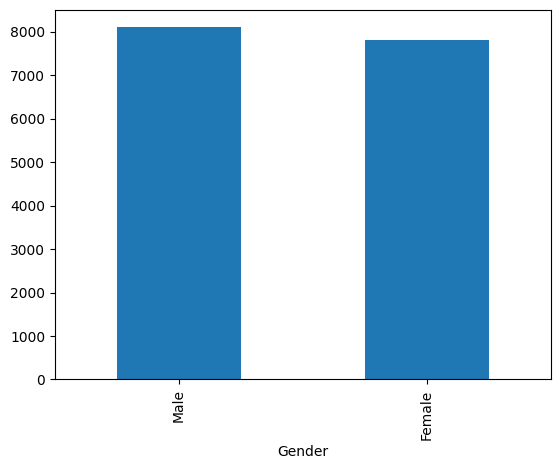

In [112]:
#Descripción variables categóricas
data['Gender'].value_counts().plot(kind='bar')

<Axes: xlabel='NumOfProducts'>

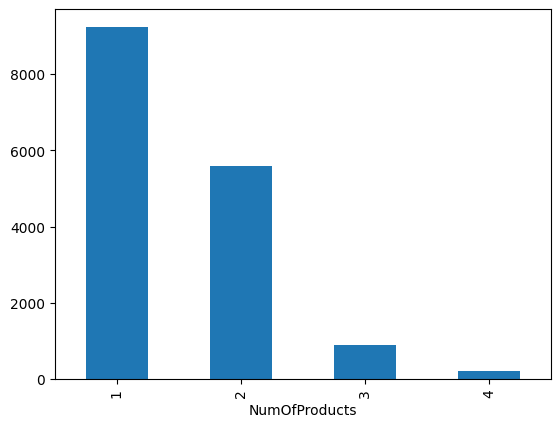

In [113]:
#Descripción variables categóricas
data['NumOfProducts'].value_counts().plot(kind='bar')

<Axes: xlabel='IsActiveMember'>

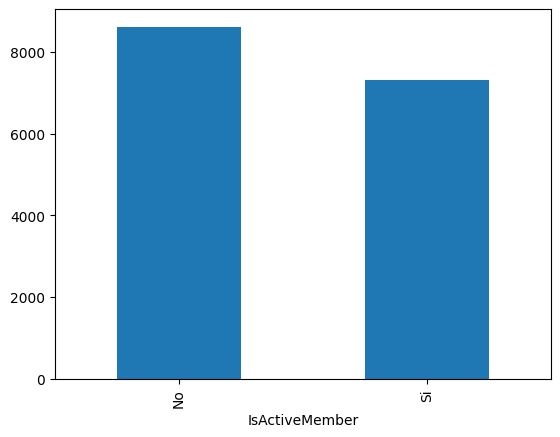

In [114]:
#Descripción variables categóricas
data['IsActiveMember'].value_counts().plot(kind='bar')

<Axes: xlabel='Exited'>

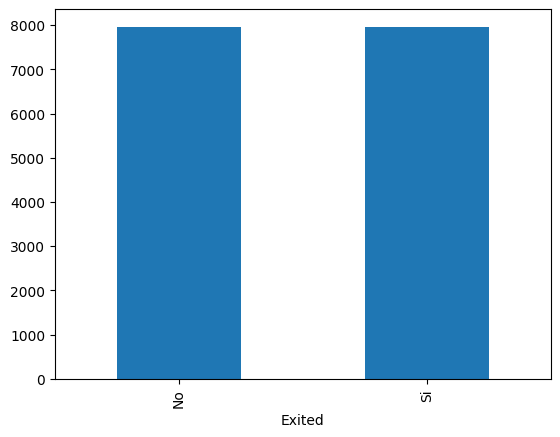

In [115]:
#Descripción variables categóricas
data['Exited'].value_counts().plot(kind='bar')

<Axes: ylabel='count'>

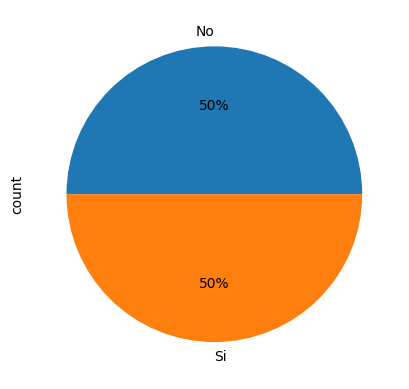

In [116]:
data['Exited'].value_counts().plot(kind='pie', autopct='%.0f%%')

In [117]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15920 entries, 0 to 15919
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   Geography       15920 non-null  category
 1   Gender          15920 non-null  category
 2   Age             15920 non-null  float64 
 3   Balance         15920 non-null  float64 
 4   NumOfProducts   15920 non-null  category
 5   IsActiveMember  15920 non-null  category
 6   Exited          15920 non-null  category
dtypes: category(5), float64(2)
memory usage: 327.3 KB


In [118]:
#Se crean dummies a las variables predictoras categóricas (no a la variable obj)
data = pd.get_dummies(data, columns=['Geography', 'NumOfProducts'], drop_first=False, dtype=int)
data = pd.get_dummies(data, columns=['Gender', 'IsActiveMember'], drop_first=True, dtype=int)
data.head()

,Age,Balance,Exited,Geography_France,Geography_Germany,Geography_Spain,NumOfProducts_1,NumOfProducts_2,NumOfProducts_3,NumOfProducts_4,Gender_Male,IsActiveMember_Si
0,42.0,0.00,Si,1,0,0,1,0,0,0,0,1
1,41.0,83807.86,No,0,0,1,1,0,0,0,0,1
2,42.0,159660.80,Si,1,0,0,0,0,1,0,0,0
3,39.0,0.00,No,1,0,0,0,1,0,0,0,0
4,43.0,125510.82,No,0,0,1,1,0,0,0,0,1


In [119]:
#Se codifican las categorias de la VARIABLE OBJETIVO (Cambiar No y Si por 0 y 1)

from sklearn.preprocessing import LabelEncoder
labelencoder = LabelEncoder()
data["Exited"]=labelencoder.fit_transform(data["Exited"]) #Objetivo

data.head()

,Age,Balance,Exited,Geography_France,Geography_Germany,Geography_Spain,NumOfProducts_1,NumOfProducts_2,NumOfProducts_3,NumOfProducts_4,Gender_Male,IsActiveMember_Si
0,42.0,0.00,1,1,0,0,1,0,0,0,0,1
1,41.0,83807.86,0,0,0,1,1,0,0,0,0,1
2,42.0,159660.80,1,1,0,0,0,0,1,0,0,0
3,39.0,0.00,0,1,0,0,0,1,0,0,0,0
4,43.0,125510.82,0,0,0,1,1,0,0,0,0,1


# 2. División 70-30

<Axes: xlabel='Exited'>

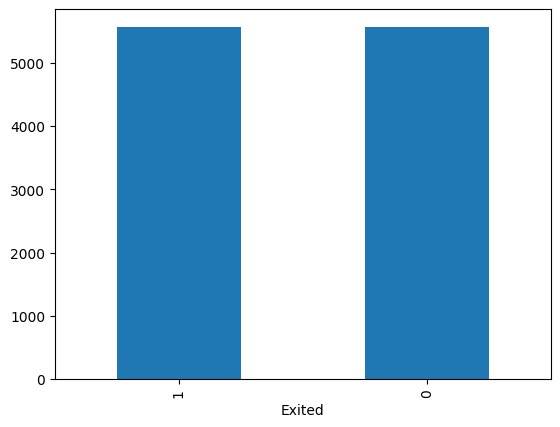

In [120]:
#División 70-30
from sklearn.model_selection import train_test_split
X = data.drop("Exited", axis = 1) # Variables predictoras
Y = data['Exited'] #Variable objetivo
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, stratify=Y) #Muestreo estratificado (cuando la variable es una categoria (solo aca), me siga el mismo patron de cantidad tanto en test como en train)
Y_train.value_counts().plot(kind='bar')

<Axes: xlabel='Exited'>

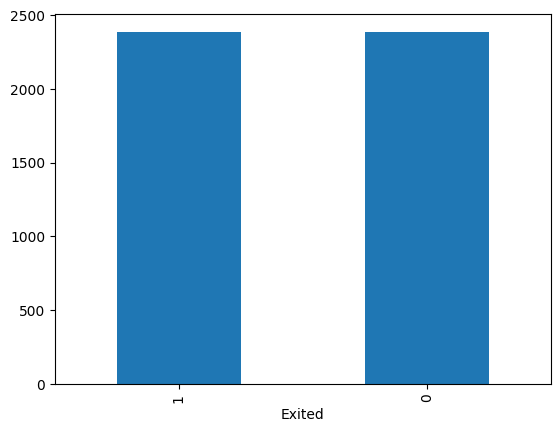

In [121]:
#Variable objetivo del 30%
Y_test.value_counts().plot(kind='bar')

# 3. Aprendizaje con el 70% y Evaluación con el 30%

In [122]:
#Dataframe para comparar los resultados
medidas= pd.DataFrame(index=['AUC'])

# **Tree**
Transformacion: discretizar, el algoritmo lo puede hacer. **No se normaliza**

In [123]:
#Creación del modelo con el conjunto de entrenamiento
from sklearn.tree import DecisionTreeClassifier #DecisionTreeRegressor

modelTree = DecisionTreeClassifier(criterion='gini', min_samples_leaf=2, max_depth=None) #gini, entropy
modelTree.fit(X_train, Y_train) #70% train

DecisionTreeClassifier(min_samples_leaf=2)

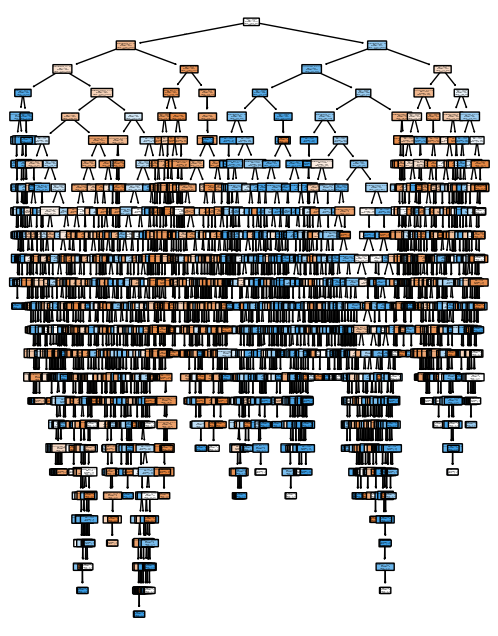

In [124]:
from sklearn.tree import plot_tree
plt.figure(figsize=(6,8)) #Tamaño de la imagen
plot_tree(modelTree, feature_names=X_train.columns.values, class_names=labelencoder.classes_, rounded=True, filled=True)
plt.show()

In [125]:
#Evaluación 30%
from sklearn import metrics

Y_pred = modelTree.predict(X_test) #30% Test
print(Y_pred)

[1 1 0 ... 0 1 1]


In [126]:
#Exactitud
exactitud=metrics.accuracy_score(y_true=Y_test, y_pred=Y_pred)
print(exactitud)

0.8553182579564489


In [127]:
#Matriz de confusion
from sklearn import metrics

cm=metrics.confusion_matrix(y_true=Y_test, y_pred=Y_pred)
cm

array([[2083,  305],
       [ 386, 2002]])

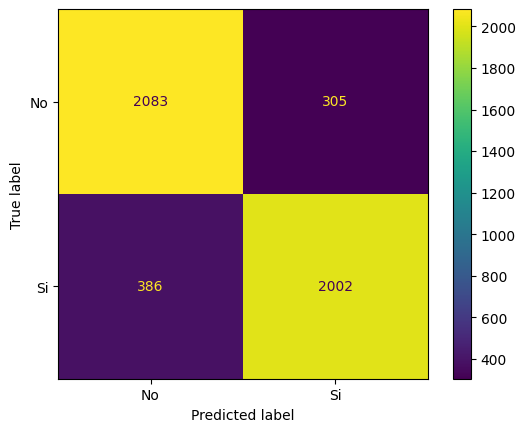

In [128]:
#Plot de la matriz de confusion
disp=metrics.ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=labelencoder.classes_)
disp.plot()

In [129]:
#Precision, Recall, f1, exactitud (REPORTE COMPLETO)
print(metrics.classification_report( y_true=Y_test, y_pred=Y_pred, target_names=labelencoder.classes_))

              precision    recall  f1-score   support

          No       0.84      0.87      0.86      2388
          Si       0.87      0.84      0.85      2388

    accuracy                           0.86      4776
   macro avg       0.86      0.86      0.86      4776
weighted avg       0.86      0.86      0.86      4776



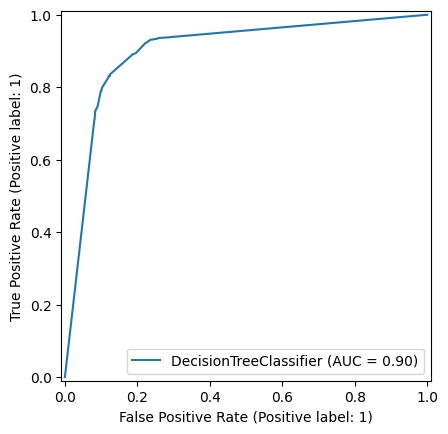

In [130]:
metrics.RocCurveDisplay.from_estimator(modelTree,X_test, Y_test)

In [131]:
# Calcular el AUC para el modelo Tree
AUC = metrics.roc_auc_score(Y_test, modelTree.predict_proba(X_test)[:, 1])

# Almacenar el AUC en el dataframe medidas
medidas['Tree']=[AUC]
print(medidas)

         Tree
AUC  0.900022


# **Random Forest**

In [132]:
#Random Forest
from sklearn.ensemble import RandomForestClassifier

model_rf= RandomForestClassifier(n_estimators=100,  max_samples=0.7, criterion='gini',
                              max_depth=None, min_samples_leaf=2) #max debe estar entre el 60-90%
model_rf.fit(X_train, Y_train) #70%

RandomForestClassifier(max_samples=0.7, min_samples_leaf=2)

              precision    recall  f1-score   support

          No       0.88      0.86      0.87      2388
          Si       0.86      0.88      0.87      2388

    accuracy                           0.87      4776
   macro avg       0.87      0.87      0.87      4776
weighted avg       0.87      0.87      0.87      4776



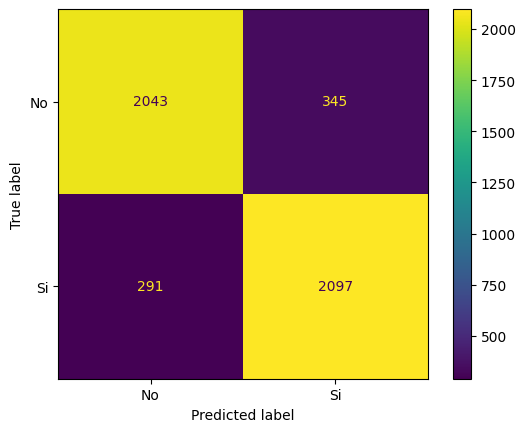

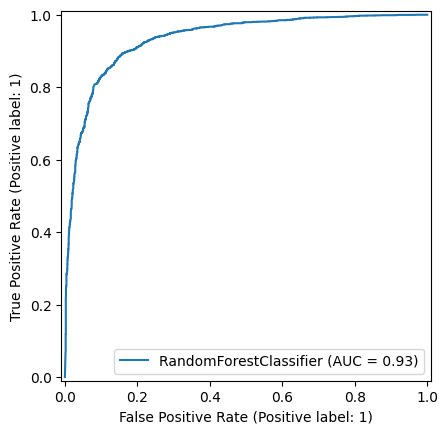

In [133]:
#Evaluación de RandomForest con 30%
from sklearn import metrics

Y_pred = model_rf.predict(X_test) #30%

#Matriz de confusion
cm=metrics.confusion_matrix(y_true=Y_test, y_pred=Y_pred)
disp=metrics.ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=labelencoder.classes_)
disp.plot()

#Precision, Recall, f1, exactitud
print(metrics.classification_report( y_true=Y_test, y_pred=Y_pred, target_names=labelencoder.classes_))

# Curva ROC
metrics.RocCurveDisplay.from_estimator(model_rf,X_test, Y_test)

In [134]:
# Calcular el AUC para el modelo Random Forest
AUC_rf = metrics.roc_auc_score(Y_test, model_rf.predict_proba(X_test)[:, 1])

# Almacenar el AUC en el dataframe medidas
medidas['Random Forest']=[AUC_rf]
print(medidas)

         Tree  Random Forest
AUC  0.900022       0.934399


# **Knn**

Para realizar este modelo, es necesario normalizar

In [135]:
X_train.head()

,Age,Balance,Geography_France,Geography_Germany,Geography_Spain,NumOfProducts_1,NumOfProducts_2,NumOfProducts_3,NumOfProducts_4,Gender_Male,IsActiveMember_Si
7265,34.0,118028.35,0,1,0,1,0,0,0,1,0
12360,40.0,0.00,1,0,0,1,0,0,0,0,1
5263,26.0,0.00,1,0,0,0,1,0,0,1,0
10987,43.0,0.00,1,0,0,1,0,0,0,0,0
5247,39.0,0.00,1,0,0,0,1,0,0,1,1


In [136]:
#Normalizacion las variables numéricas (las dummies no se normalizan)
from sklearn.preprocessing import MinMaxScaler

min_max_scaler = MinMaxScaler()
min_max_scaler.fit(data[['Age','Balance']]) #Ajuste de los parametros sobre 100% de los datos (data): max - min

#Se aplica la normalización a 70%  y 30%
X_train[['Age','Balance']]= min_max_scaler.transform(X_train[['Age','Balance']]) #70%
X_test[['Age','Balance']]= min_max_scaler.transform(X_test[['Age','Balance']]) #30%
X_train.head()

,Age,Balance,Geography_France,Geography_Germany,Geography_Spain,NumOfProducts_1,NumOfProducts_2,NumOfProducts_3,NumOfProducts_4,Gender_Male,IsActiveMember_Si
7265,0.216216,0.470423,0,1,0,1,0,0,0,1,0
12360,0.297297,0.000000,1,0,0,1,0,0,0,0,1
5263,0.108108,0.000000,1,0,0,0,1,0,0,1,0
10987,0.337838,0.000000,1,0,0,1,0,0,0,0,0
5247,0.283784,0.000000,1,0,0,0,1,0,0,1,1


In [137]:
#Aprendizaje KNN con 70%
from sklearn.neighbors  import KNeighborsClassifier #KNeighborsRegressor

modelKnn = KNeighborsClassifier(n_neighbors=1, metric='euclidean')#euclidean, minkowski
modelKnn.fit(X_train, Y_train) #70%

KNeighborsClassifier(metric='euclidean', n_neighbors=1)

              precision    recall  f1-score   support

          No       0.88      0.83      0.85      2388
          Si       0.84      0.89      0.86      2388

    accuracy                           0.86      4776
   macro avg       0.86      0.86      0.86      4776
weighted avg       0.86      0.86      0.86      4776



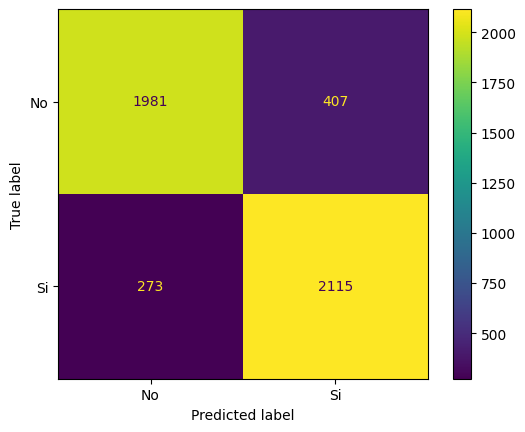

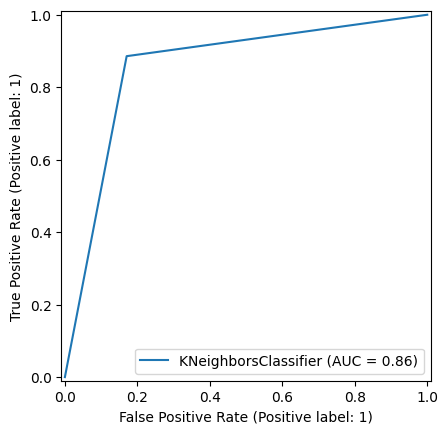

In [138]:
#Evaluación de Knn con 30%
from sklearn import metrics

Y_pred = modelKnn.predict(X_test) #30%

#Matriz de confusion
cm=metrics.confusion_matrix(y_true=Y_test, y_pred=Y_pred)
disp=metrics.ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=labelencoder.classes_)
disp.plot()

#Precision, Recall, f1, exactitud
print(metrics.classification_report( y_true=Y_test, y_pred=Y_pred, target_names=labelencoder.classes_))

# Curva ROC
metrics.RocCurveDisplay.from_estimator(modelKnn,X_test, Y_test)

In [139]:
# Calcular el AUC para el modelo KNN
AUC_knn = metrics.roc_auc_score(Y_test, modelKnn.predict_proba(X_test)[:, 1])

# Almacenar el AUC en el dataframe medidas
medidas['KNN']=[AUC_knn]
print(medidas)

         Tree  Random Forest       KNN
AUC  0.900022       0.934399  0.857621


# **Red Neuronal**

Para realizar este modelo, es necesario normalizar

In [163]:
#Red Neuronal

from sklearn.neural_network import MLPClassifier #MLPRegressor

#Solo se configura capas ocultas, no se configura capa de entrada y de salida
#activation -> función activación de la oculta: sigmoid, logistic, linear
#hidden_layer_sizes=5,7 -> dos capas ocultas con 5 neuronas y 7 neuronas
#learning_rate-> tamaño del paso constante o decreciente (constant, adaptive)
#learning_rate_init-> valor tasa de aprendizaje
#momentum-> valor momentum
#max_iter-> iteaciones
#random_state-> semilla para generacion numeros seudoaletorios
modelNN = MLPClassifier(activation="relu",hidden_layer_sizes=(5,7), learning_rate='adaptive', #constant
                     learning_rate_init=0.02, momentum= 0.6, max_iter=500, random_state=3)

modelNN.fit(X_train, Y_train) #70% normalizados

MLPClassifier(hidden_layer_sizes=(5, 7), learning_rate='adaptive',
              learning_rate_init=0.02, max_iter=500, momentum=0.6,
              random_state=3)

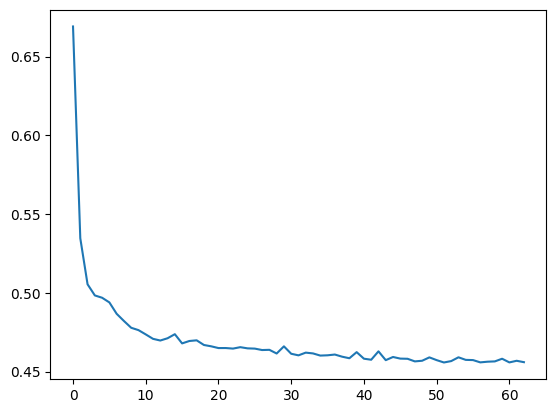

In [164]:
#Loss es la desviación entre Y_train y el Y_pred
# En la grafica se presenta ciertos picos que no es para nada BUENO
# Se probaron todas las posibles combinaciones pero no funciono
loss_values = modelNN.loss_curve_
plt.plot(loss_values)

              precision    recall  f1-score   support

          No       0.78      0.80      0.79      2388
          Si       0.80      0.78      0.79      2388

    accuracy                           0.79      4776
   macro avg       0.79      0.79      0.79      4776
weighted avg       0.79      0.79      0.79      4776



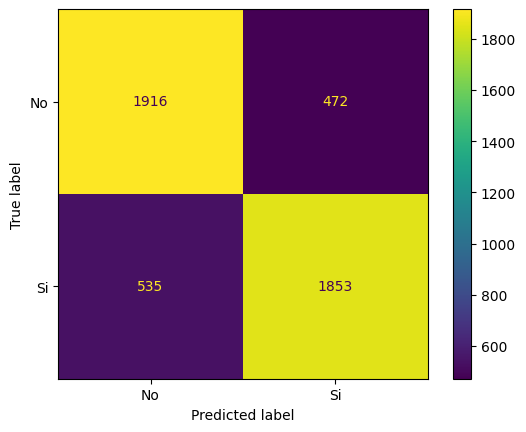

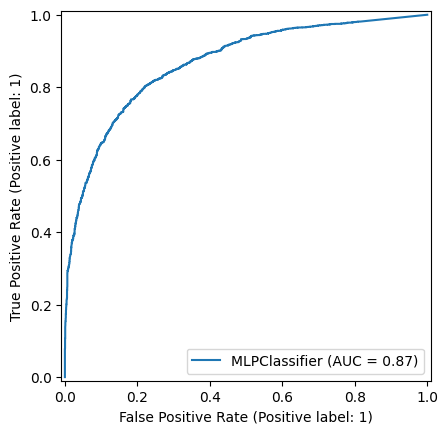

In [165]:
#Evaluación de Red Neuronal
from sklearn import metrics

Y_pred = modelNN.predict(X_test) #30%

#Matriz de confusion
cm=metrics.confusion_matrix(y_true=Y_test, y_pred=Y_pred)
disp=metrics.ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=labelencoder.classes_)
disp.plot()

#Precision, Recall, f1, exactitud
print(metrics.classification_report( y_true=Y_test, y_pred=Y_pred, target_names=labelencoder.classes_))

# Curva ROC
metrics.RocCurveDisplay.from_estimator(modelNN,X_test, Y_test)

In [166]:
# Calcular el AUC para el modelo Red Neuronal
AUC_nn = metrics.roc_auc_score(Y_test, modelNN.predict_proba(X_test)[:, 1])

# Almacenar el AUC en el dataframe medidas
medidas['Red Neuronal']=[AUC_nn]
print(medidas)

         Tree  Random Forest       KNN  Red Neuronal
AUC  0.900022       0.934399  0.857621      0.866751


# **SVM**

Para realizar este modelo, es necesario normalizar

In [180]:
#SVM
from sklearn.svm import SVC # SVR

modelSVM = SVC(kernel='poly', probability=True) #'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'
modelSVM.fit(X_train, Y_train) #70%

SVC(kernel='poly', probability=True)

              precision    recall  f1-score   support

          No       0.77      0.80      0.79      2388
          Si       0.79      0.77      0.78      2388

    accuracy                           0.78      4776
   macro avg       0.78      0.78      0.78      4776
weighted avg       0.78      0.78      0.78      4776



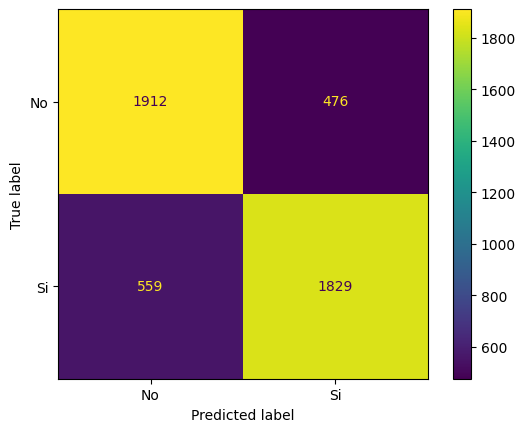

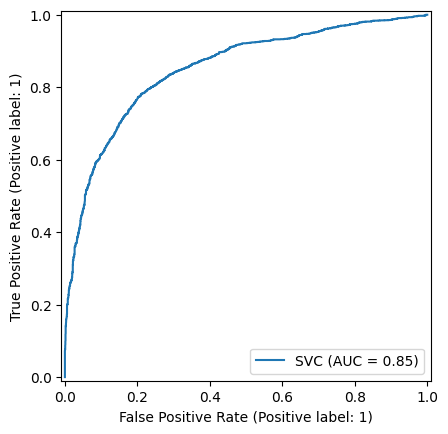

In [181]:
#Evaluación de SVM
from sklearn import metrics

Y_pred = modelSVM.predict(X_test) #30%

#Matriz de confusion
cm=metrics.confusion_matrix(y_true=Y_test, y_pred=Y_pred)
disp=metrics.ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=labelencoder.classes_)
disp.plot()

#Precision, Recall, f1, exactitud
print(metrics.classification_report( y_true=Y_test, y_pred=Y_pred, target_names=labelencoder.classes_))

# Curva ROC
metrics.RocCurveDisplay.from_estimator(modelSVM,X_test, Y_test)

In [182]:
# Calcular el AUC para el modelo SVM
AUC_svm = metrics.roc_auc_score(Y_test, modelSVM.predict_proba(X_test)[:, 1])

# Almacenar el AUC en el dataframe medidas
medidas['SVM']=[AUC_svm]
print(medidas)

         Tree  Random Forest       KNN  Red Neuronal       SVM
AUC  0.900022       0.934399  0.857621      0.866751  0.851215


# **CONCLUSIÓN**
En general, los resultados obtenidos muestran un buen desempeño de los modelos evaluados, con valores de AUC superiores a 0.85 en todos los casos, lo que indica una adecuada capacidad de discriminación entre clases. El modelo de Random Forest presenta el mejor rendimiento con un AUC de 0.9344, destacándose por su estabilidad y capacidad para manejar relaciones no lineales y variables correlacionadas.

El árbol de decisión también logra un desempeño sólido (AUC = 0.9000), aunque con menor generalización. En contraste, el KNN y la red neuronal muestran un rendimiento aceptable pero inferior, siendo posible que los picos en la gráfica de pérdida del KNN reflejen sensibilidad al ruido o una mala elección de hiperparámetros (como k o la escala de las variables). Finalmente, el SVM obtuvo el AUC más bajo (0.8512), aunque sigue dentro de un rango considerado bueno.

En conclusión, el **Random Forest** se posiciona como el modelo más robusto y confiable para este conjunto de datos, combinando alto desempeño y estabilidad

In [183]:
# Guardar Metodo Random Forest
import pickle
filename = 'modelo_RF-class.pkl'
variables= X.columns._values
pickle.dump([model_rf,labelencoder,variables,min_max_scaler], open(filename, 'wb'))

In [184]:
# Para la Hiperparametrización, guardamos el modelo Tree, ya que es mucho mas eficiente para esto
import pickle
filename = 'modelo_Tree-class.pkl'
variables= X.columns._values
pickle.dump([modelTree,labelencoder,variables,min_max_scaler], open(filename, 'wb'))